In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

### The Logistic Regression Equation

Unlike **Decision Trees** (which use if/else rules)

**Logistic Regression** uses **probability** to make predictions.

| Model | Logic | Output |
|-------|-------|--------|
| **Decision Tree** | If/else rules | Binary: Yes/No |
| **Logistic Regression** | Probability | Score: 0% to 100% |

Logistic Regression uses the Sigmoid Function to convert any number into a probability (0 to 1):


$$
P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n)}}
$$


z = 2.5 → sigmoid(2.5) = 0.924 → 92.4% probability of passing

z = -1.3 → sigmoid(-1.3) = 0.214 → 21.4% probability of passing

z = 0 → sigmoid(0) = 0.5 → 50% probability (decision boundary)

In [22]:
np.random.seed(42)

n_students = 50
study_hours = np.random.uniform(0, 10, n_students)  # 0-10 hours studied
sleep_hours = np.random.uniform(3, 9, n_students)   # 3-9 hours sleep

# Pass if: study_hours > 5 AND sleep_hours > 5
pass_prob = 1 / (1 + np.exp(-(study_hours - 5) * 0.8 - (sleep_hours - 5) * 0.3))
pass_exam = np.random.binomial(1, pass_prob)

data = pd.DataFrame({
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'passed': pass_exam
})

print("="*60)
print("STUDENT PASS/FAIL DATASET")
print("="*60)
print(data.head(10))
print(f"\nTotal students: {len(data)}")
print(f"Passed: {data['passed'].sum()}")
print(f"Failed: {len(data) - data['passed'].sum()}")

STUDENT PASS/FAIL DATASET
   study_hours  sleep_hours  passed
0     3.745401     8.817508       1
1     9.507143     7.650797       1
2     7.319939     8.636994       1
3     5.986585     8.368964       1
4     1.560186     6.587400       1
5     1.559945     8.531245       0
6     0.580836     3.530955       0
7     8.661761     4.175897       1
8     6.011150     3.271364       1
9     7.080726     4.951982       1

Total students: 50
Passed: 27
Failed: 23


In [26]:
# split
X = data[['study_hours', 'sleep_hours']]
y = data['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_prob = model.predict_proba(X_test)  # probabilities

In [24]:
print("\n" + "="*60)
print("PROBABILITY PREDICTIONS (THE MAGIC!)")
print("="*60)
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = y_pred
results['prob_fail'] = y_prob[:, 0]  # Probability of failing
results['prob_pass'] = y_prob[:, 1]  # Probability of passing
results['confidence'] = np.max(y_prob, axis=1) * 100
print(results.round(2))


print("\n" + "="*60)
print("MODEL COEFFICIENTS (WHAT THEY MEAN)")
print("="*60)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
})
print(coef_df)
print("\nInterpretation:")
for i, row in coef_df.iterrows():
    if row['Coefficient'] > 0:
        print(f"  ✅ {row['Feature']}: +{row['Coefficient']:.3f}")
        print(f"     → Each extra hour increases odds of passing by {row['Odds_Ratio']:.2f}x")
    else:
        print(f"  ❌ {row['Feature']}: {row['Coefficient']:.3f}")
        print(f"     → Each extra hour decreases odds of passing by {1/row['Odds_Ratio']:.2f}x")
print(f"\nIntercept: {model.intercept_[0]:.3f}")


PROBABILITY PREDICTIONS (THE MAGIC!)
    study_hours  sleep_hours  actual  predicted  prob_fail  prob_pass  \
23         3.66         7.89       0          1       0.29       0.71   
16         3.04         3.85       0          0       0.88       0.12   
32         0.65         4.99       0          0       0.99       0.01   
44         2.59         7.63       0          0       0.64       0.36   
28         5.92         5.15       1          1       0.09       0.91   
38         6.84         8.32       1          1       0.01       0.99   
47         5.20         5.57       1          1       0.17       0.83   
18         4.32         3.45       1          0       0.65       0.35   
19         2.91         8.92       0          1       0.37       0.63   
45         6.63         5.96       1          1       0.03       0.97   

    confidence  
23       71.46  
16       88.04  
32       98.75  
44       63.66  
28       90.69  
38       99.39  
47       83.15  
18       65.02  
19   

In [28]:
target_names = ['Fail', 'Pass']

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# accuracy
test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = accuracy_score(y_train, y_pred_train)
gap = train_accuracy - test_accuracy
print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Overfitting Gap: {gap:.4f}")


if gap < 0.01:
    print("✅ NO OVERFITTING (gap < 1%)")
    status = "Balanced"
elif gap < 0.02:
    print("✅ MINIMAL OVERFITTING (1-2%)")
    status = "Slight Overfitting"
elif gap < 0.03:
    print("⚠️  MILD OVERFITTING (2-3%)")
    status = "Mild Overfitting"
elif gap < 0.05:
    print("⚠️  MODERATE OVERFITTING (3-5%)")
    status = "Moderate Overfitting"
elif gap < 0.10:
    print("🔴 SIGNIFICANT OVERFITTING (5-10%)")
    status = "Significant Overfitting"
else:
    print("🔴 SEVERE OVERFITTING (>10%)")
    status = "Severe Overfitting"

if train_accuracy < 0.70 and test_accuracy < 0.70:
    print("📉 UNDERFITTING DETECTED: Model is too simple")
elif train_accuracy < 0.75:
    print("⚠️  Possible underfitting (training accuracy < 75%)")
else:
    print("✅ No underfitting detected")

# detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
correct_predictions = np.trace(cm)
total_predictions = np.sum(cm)
accuracy = correct_predictions / total_predictions

print("\nConfusion Matrix:")
print(cm)


print(f"Correct predictions: {correct_predictions}")
print(f"Total predictions: {total_predictions}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

for i in range(cm.shape[0]):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    accuracy = class_correct / class_total
    print(f"{target_names[i]} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


MODEL EVALUATION
Training Accuracy: 95.00%
Test Accuracy: 70.00%
Overfitting Gap: 0.2500
🔴 SEVERE OVERFITTING (>10%)
✅ No underfitting detected

Classification Report:
              precision    recall  f1-score   support

        Fail       0.75      0.60      0.67         5
        Pass       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10


Confusion Matrix:
[[3 2]
 [1 4]]
Correct predictions: 7
Total predictions: 10
Accuracy: 0.7000
Accuracy: 70.00%
Fail Accuracy: 0.6000 (60.00%)
Pass Accuracy: 0.8000 (80.00%)


C:\Users\rah\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


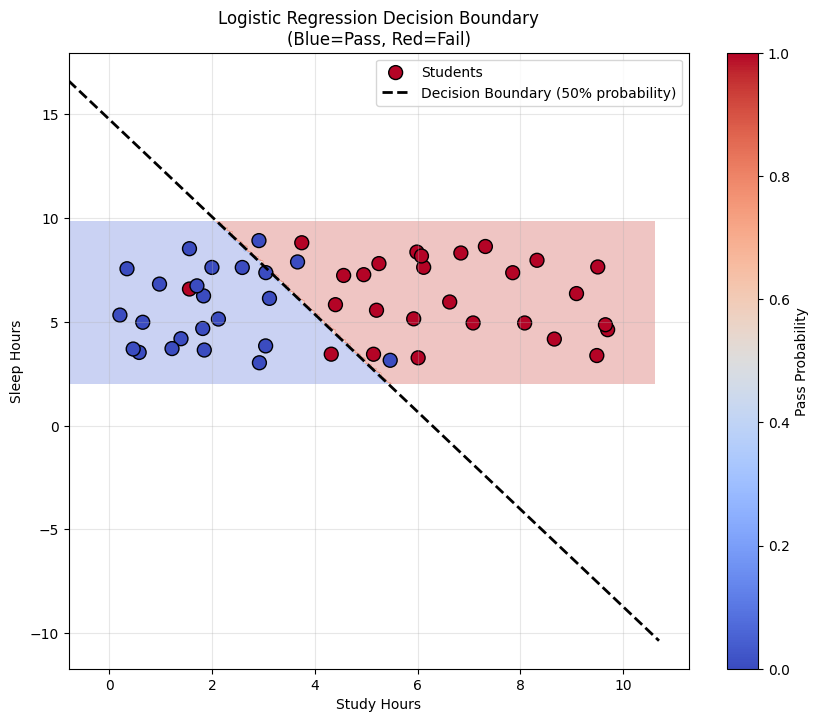

In [12]:
# plot
x_min, x_max = X['study_hours'].min() - 1, X['study_hours'].max() + 1
y_min, y_max = X['sleep_hours'].min() - 1, X['sleep_hours'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['study_hours'], X['sleep_hours'], c=y, cmap='coolwarm', 
            edgecolors='black', s=100, label='Students')
plt.xlabel('Study Hours')
plt.ylabel('Sleep Hours')
plt.title('Logistic Regression Decision Boundary\n(Blue=Pass, Red=Fail)')
plt.colorbar(label='Pass Probability')
plt.grid(True, alpha=0.3)

# Plot the decision boundary (where probability = 0.5)
# The boundary is: coefficient_0 * study_hours + coefficient_1 * sleep_hours + intercept = 0
coef0, coef1 = model.coef_[0]
intercept = model.intercept_[0]

# Line: coef0*x + coef1*y + intercept = 0 → y = (-coef0*x - intercept) / coef1
x_line = np.array([x_min, x_max])
y_line = (-coef0 * x_line - intercept) / coef1
plt.plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary (50% probability)')

plt.legend()
plt.show()

In [18]:
# Multiclass: Iris species (3 classes)
iris = load_iris()
X = iris.data
y = iris.target  # 0, 1, 2 (3 classes)

log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)

print(f"Accuracy: {log_reg.score(X, y):.4f}")

Accuracy: 0.9733
